# BCSD Pipeline Demo

This notebook demonstrates the BCSD downscaling pipeline. It covers:

- Pydantic-based configuration (`BCSDConfig`)
- Automatic caching with S3 (via `ArtifactCache`)
- Three-stage architecture: observations → historical → scenario
- Environment-based isolation (`qa` / `production`)
- **Ensemble member lineage resolution** for G6 / SAI scenarios (new in v0.5)

We run a South Africa regional downscaling for CESM2-WACCM / `tas` / SSP245 and
visualise the results, then show how to configure a G6-1.5K run with correct lineage.

In [1]:
import duckdb
import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

from srm.bcsd_config import BCSDConfig
from srm.orchestration import BCSDOrchestrator
from srm.pipeline import BCSDPipeline

## 1. Define Configuration

we'll configure a BCSD run for:
- GCM: CESM2-WACCM
- Variable: tas (temperature)
- Scenario: SSP245
- Region: South Africa
- Environment: qa (for testing)

In [2]:
# Define South Africa bounds
df = duckdb.sql(
    """
    install httpfs; load httpfs;
    install spatial; load spatial;
    SELECT name, ST_AsText(geom) as geometry
    FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json')
    WHERE NAME = 'South Africa'
    """
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds with 2-degree buffer
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
bounds = [lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
bounds = [round(entry, 2) for entry in bounds]

print(f"South Africa subset bounds: {bounds}")

South Africa subset bounds: [np.float64(-48.96), np.float64(-20.15), np.float64(14.45), np.float64(39.89)]


In [3]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="001",  # NCAR-format label used in the SSP245 store
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",  # renamed from cache_dir in v0.4
    output_dir="s3://carbonplan-scratch/srm/output",
    environment="qa",
    verbose=True,
)

print(f"Run ID:      {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Version:     {config.version}")
print(f"Detrend:     {config.detrend_data}")

Run ID:      CESM2-WACCM_tas_001_SSP245_subset
Config hash: 5fe735ff7b57
Version:     v999
Detrend:     True


## 1b. Ensemble Member Lineage (G6 / SAI scenarios)

For SSP245 and other CMIP6-standard scenarios the `ensemble_member` label in
`BCSDConfig` maps directly to the coordinate label in the store, so no special
handling is needed.

For **G6 and other SAI scenarios** this breaks down: the G6 ensemble member
label (e.g. `"001"`) does not match the label used in the historical store
(`"r1i1p1f1"`) or the SSP245 bridge store. `srm.lineage.resolve_member_lineage`
encodes the correct mapping for every `(gcm, scenario, member, variable)` combination:

| Field | Used by |
|---|---|
| `historical_ensemble_member` | `.sel()` when loading historical GCM data |
| `ssp245_ensemble_member` | `.sel()` when loading the SSP245 bridge run (SAI only) |

**Lineage is resolved automatically** — both `BCSDPipeline` (at `__init__` time)
and the CLI (`bcsd run` / `bcsd run-matrix`, before dispatch) call
`resolve_member_lineage` and populate the two fields. You never need to set
them manually; pre-set values are always respected if you do.

In [4]:
from srm.cli import _print_lineage_summary, _resolve_lineage
from srm.lineage import resolve_member_lineage

# Direct lookup — useful when you need to inspect the mapping before running.
hist, ssp245 = resolve_member_lineage("CESM2-WACCM", "G6-1.5K", "001", "tas")
print(f"G6 001/tas    → historical={hist!r:12s}  ssp245_bridge={ssp245!r}")

# tasmax/tasmin use a corrected NCAR-provided historical run labelled "001".
hist_tmx, ssp245_tmx = resolve_member_lineage("CESM2-WACCM", "G6-1.5K", "001", "tasmax")
print(f"G6 001/tasmax → historical={hist_tmx!r:12s}  ssp245_bridge={ssp245_tmx!r}")

# --- BCSDPipeline resolves lineage automatically at __init__ time ---
# Just pass the raw config; historical_ensemble_member and ssp245_ensemble_member
# are populated on self.config before any data is touched.

g6_config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="001",
    scenario="G6-1.5K",
    predict_period_start=2015,
    predict_period_end=2084,
    subset_bounds=tuple(bounds),
    scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/output",
    environment="qa",
    # No need to set historical_ensemble_member / ssp245_ensemble_member —
    # BCSDPipeline fills them in.
)
g6_pipeline = BCSDPipeline(g6_config)  # logs: "Lineage resolved — ..."

print("\nAfter BCSDPipeline init:")
print(f"  ensemble_member:            {g6_pipeline.config.ensemble_member}")
print(f"  historical_ensemble_member: {g6_pipeline.config.historical_ensemble_member}")
print(f"  ssp245_ensemble_member:     {g6_pipeline.config.ssp245_ensemble_member}")

# --- Batch resolution (CLI helper) ---
# _resolve_lineage pre-populates fields on all configs before they reach the
# orchestrator — useful when you want to inspect or validate the mapping first.


g6_configs = [
    BCSDConfig(
        gcm="CESM2-WACCM",
        variable=var,
        ensemble_member=member,
        scenario="G6-1.5K",
        predict_period_start=2015,
        predict_period_end=2084,
        scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",
        output_dir="s3://carbonplan-scratch/srm/output",
        environment="qa",
    )
    for member in ("001", "002", "003")
    for var in ("tas", "pr", "rsds", "tasmax")
]
g6_configs = _resolve_lineage(g6_configs)
_print_lineage_summary(g6_configs)

G6 001/tas    → historical='r1i1p1f1'    ssp245_bridge='001'
G6 001/tasmax → historical='001'         ssp245_bridge='009'

After BCSDPipeline init:
  ensemble_member:            001
  historical_ensemble_member: r1i1p1f1
  ssp245_ensemble_member:     001


          Ensemble Member Lineage (12 config(s) resolved)           
                                                                    
  GCM           Variable   Member   → Historical   → SSP245 Bridge  
 ────────────────────────────────────────────────────────────────── 
  CESM2-WACCM   tas           001       r1i1p1f1               001  
  CESM2-WACCM   pr            001       r1i1p1f1               001  
  CESM2-WACCM   rsds          001       r1i1p1f1               001  
  CESM2-WACCM   tasmax        001            001               009  
  CESM2-WACCM   tas           002       r2i1p1f1               002  
  CESM2-WACCM   pr            002       r2i1p1f1               002  
  CESM2-WACCM   rsds          002       r2i1p1f1               002  
  CESM2-WACCM   tasmax        002            001               007  
  CESM2-WACCM   tas           003       r3i1p1f1               003  
  CESM2-WACCM   pr            003       r3i1p1f1               003  
  CESM2-WACCM   rsds          003       r3i1p1f1               003  
  CESM2-WACCM   tasmax        003            001               008 

## 2. Run Pipeline

we can run the pipeline either:
- **Locally**: `use_coiled=False` - good for testing small regions
- **Coiled**: `use_coiled=True` - for large-scale runs

for this demo, we'll run locally since it's a small region.

In [5]:
# Initialize pipeline
pipeline = BCSDPipeline(config)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path}")

[05:51:27] INFO     Lineage resolved — ensemble_member='001'  historical='r1i1p1f1'

Stage 1: Prepare observations (regrid ERA5 to GCM grid)


           INFO     ✓ Using cached observations:                                                                   
                    s3://carbonplan-scratch/srm/bcsd-cache/qa/v999/obs/CESM2-WACCM/tas/lat-48.96to-20.15_lon14.45to
                    39.89/obs_regridded.icechunk

✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v999/obs/CESM2-WACCM/tas/lat-48.96to-20.15_lon14.45to39.89/obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)


[05:51:28] INFO     ✓ Using cached historical:                                                                     
                    s3://carbonplan-scratch/srm/output/qa/v999/historical/CESM2-WACCM/tas/r1i1p1f1/lat-48.96to-20.1
                    5_lon14.45to39.89/286fe410/historical.icechunk

...

           INFO     Computing scenario downscaling for CESM2-WACCM/tas/001/SSP245

[05:51:29] INFO     Loaded data (1.36s)

[05:51:37] INFO     Rechunked for detrending (7.66s)

/scratch/synced/src/srm/pipeline.py:212: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  result = xr.concat(


TypeError: cannot compare cftime.DatetimeNoLeap(2039, 7, 2, 0, 0, 0, 0, has_year_zero=True) and Timestamp('1978-01-01 00:00:00') (different calendars)

In [5]:
# import icechunk
bucket = "carbonplan-scratch"
prefix = "srm/bcsd-cache/qa/v1/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk"


def open_icechunk(path):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

## 3. Load Results from Cache

the pipeline automatically caches intermediate artifacts and final outputs. let's load them for visualization.

In [6]:
bucket, prefix = obs_path.replace("s3://", "").split("/", 1)
bucket, prefix

('carbonplan-scratch',
 'srm/bcsd-cache/qa/v1/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk')

In [7]:
# Load cached artifacts
obs_coarse = open_icechunk(obs_path)[config.variable]
historical_downscaled = open_icechunk(hist_path)[config.variable]
scenario_downscaled = open_icechunk(scenario_path)[config.variable]

print("Observations (coarse):", obs_coarse)
print("Historical downscaled:", historical_downscaled)
print("Scenario downscaled:", scenario_downscaled)

Observations (coarse): <xarray.DataArray 'tas' (time: 23741, lat: 31, lon: 20)> Size: 59MB
dask.array<open_dataset-tas, shape=(23741, 31, 20), dtype=float32, chunksize=(30, 31, 20), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 190kB 1950-01-01 1950-01-02 ... 2014-12-31
  * lat      (lat) float64 248B -48.53 -47.59 -46.65 ... -22.15 -21.2 -20.26
  * lon      (lon) float64 160B 15.0 16.25 17.5 18.75 ... 35.0 36.25 37.5 38.75
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K
Historical downscaled: <xarray.DataArray 'tas' (time: 13505, lat: 115, lon: 102)> Size: 634MB
dask.array<open_dataset-tas, shape=(13505, 115, 102), dtype=float32, chunksize=(2234, 115, 102), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
    dayofyear  (time) int64 108kB dask.array<chunksize=(2234,), meta=np.ndarray>
  * lat        (lat) float32 460B -48.75 -48.5 -48.25 ... -20.75 -

In [ ]:
# Also load the raw GCM data for comparison
from srm.downscaling_utils import get_experiment, get_obs, subset_space

# Load fine-resolution observations
obs_fine = get_obs(var=config.variable)
obs_fine = subset_space(obs_fine, bounds)
obs_fine = obs_fine.sel(time=slice("1978", "2014"))

# Load coarse GCM data — scenario labels are lowercase in the catalog
model_hist_raw = get_experiment(gcm=config.gcm, scenario="historical", var=config.variable)
if "ensemble_member" in model_hist_raw.dims:
    model_hist_raw = model_hist_raw.sel(ensemble_member=config.ensemble_member)
model_hist_raw = subset_space(model_hist_raw, bounds)
model_hist_raw = model_hist_raw.sel(time=slice("1978", "2014"))

model_scenario_raw = get_experiment(gcm=config.gcm, scenario=config.scenario, var=config.variable)
model_scenario_raw = model_scenario_raw.sel(ensemble_member=config.ensemble_member)
model_scenario_raw = subset_space(model_scenario_raw, bounds)
model_scenario_raw = model_scenario_raw.sel(time=slice("2015", "2100"))

print("Loaded raw GCM data for comparison")

## 4. Visualize Results at Cape Town

extract time series at Cape Town and compare:
1. raw model output (coarse)
2. debiased model output (coarse)
3. debiased + downscaled output (fine resolution)

In [9]:
# Get Cape Town coordinates
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_lon = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x.item())
cape_town_lat = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y.item())

print(f"Cape Town: ({cape_town_lat:.2f}°, {cape_town_lon:.2f}°)")

Cape Town: (-33.92°, 18.43°)


In [10]:
# Extract Cape Town data
obs_fine_ct = obs_fine.sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest").compute()
obs_coarse_ct = obs_coarse.sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest").compute()

model_hist_raw_ct = model_hist_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct = historical_downscaled.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

model_scenario_raw_ct = model_scenario_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct = scenario_downscaled.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

print("✓ Extracted Cape Town time series")

✓ Extracted Cape Town time series


### Distribution Comparison: Raw → Debiased → Downscaled

this shows how BCSD transforms the model output:
- **Left**: Raw GCM output (biased, coarse)
- **Middle**: after bias correction (matches obs distribution, coarse)
- **Right**: after bias correction + spatial disaggregation (fine resolution)

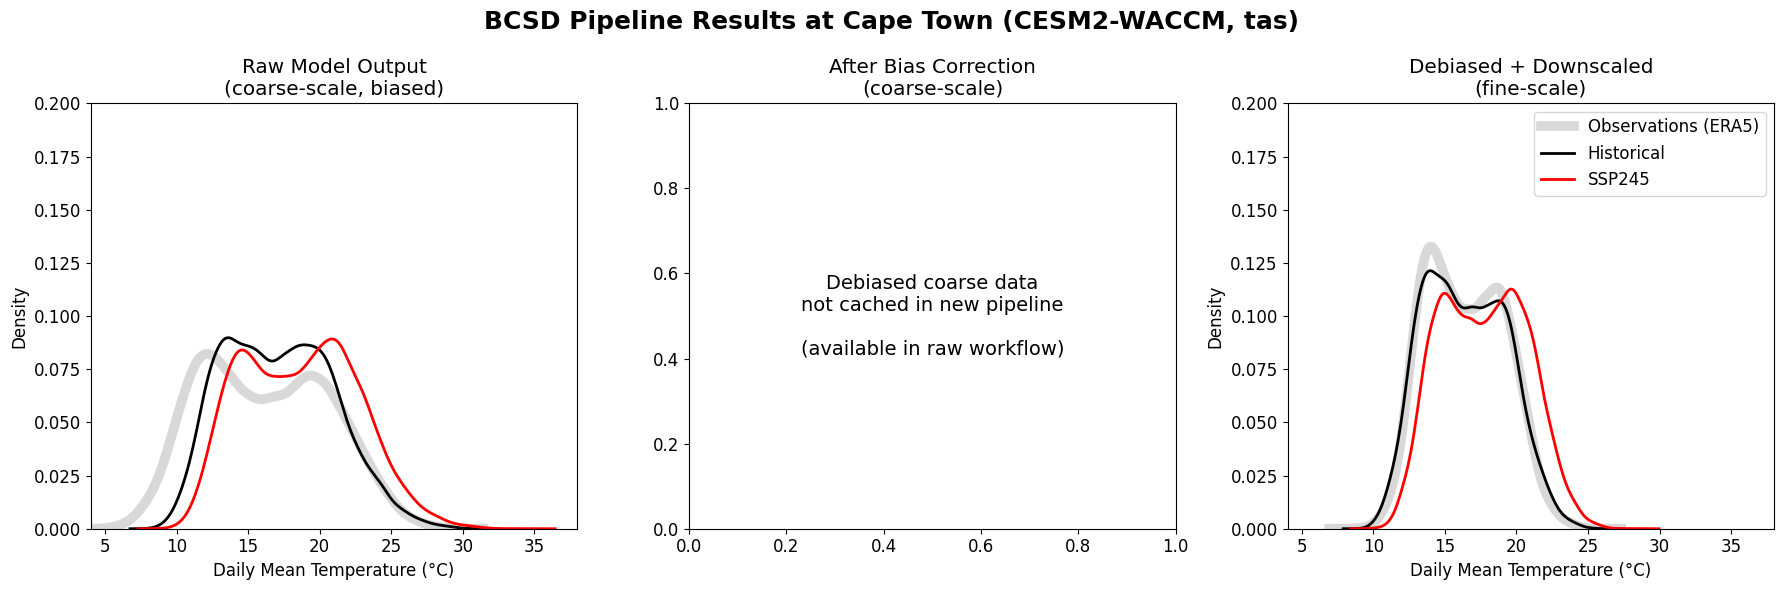

In [11]:
# Note: For the debiased coarse data, we need to compute it since pipeline doesn't cache it
# In production, we might want to cache the intermediate debiased-but-not-downscaled data

# Create figure
plt.rcParams["font.size"] = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["black", "red"]
labels = ["Historical", "SSP245"]


def format_subplot(ax, res="coarse"):
    """Add observation distribution to subplot"""
    if res == "coarse":
        sns.kdeplot(
            obs_coarse_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    elif res == "fine":
        sns.kdeplot(
            obs_fine_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    ax.set_ylim([0, 0.2])
    ax.set_xlim([4, 38])
    ax.set_xlabel("Daily Mean Temperature (°C)")


# Panel 1: Raw model output
ax = axes[0]
format_subplot(ax, res="coarse")
sns.kdeplot(
    model_hist_raw_ct.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    model_scenario_raw_ct.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Raw Model Output\n(coarse-scale, biased)")

# Panel 2: Note - we don't have direct access to debiased-but-not-downscaled
# This would require modifying the pipeline to cache that intermediate step
# For now, we'll skip this panel or note it as unavailable
ax = axes[1]
ax.text(
    0.5,
    0.5,
    "Debiased coarse data\nnot cached in new pipeline\n\n(available in raw workflow)",
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=14,
)
ax.set_title("After Bias Correction\n(coarse-scale)")

# Panel 3: Downscaled output
ax = axes[2]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Debiased + Downscaled\n(fine-scale)")

plt.suptitle(
    f"BCSD Pipeline Results at Cape Town ({config.gcm}, {config.variable})",
    fontsize=18,
    fontweight="bold",
)

axes[2].legend(fontsize=12)
plt.tight_layout()
plt.show()

### Time Series Comparison

let's also look at the annual mean temperature trends:

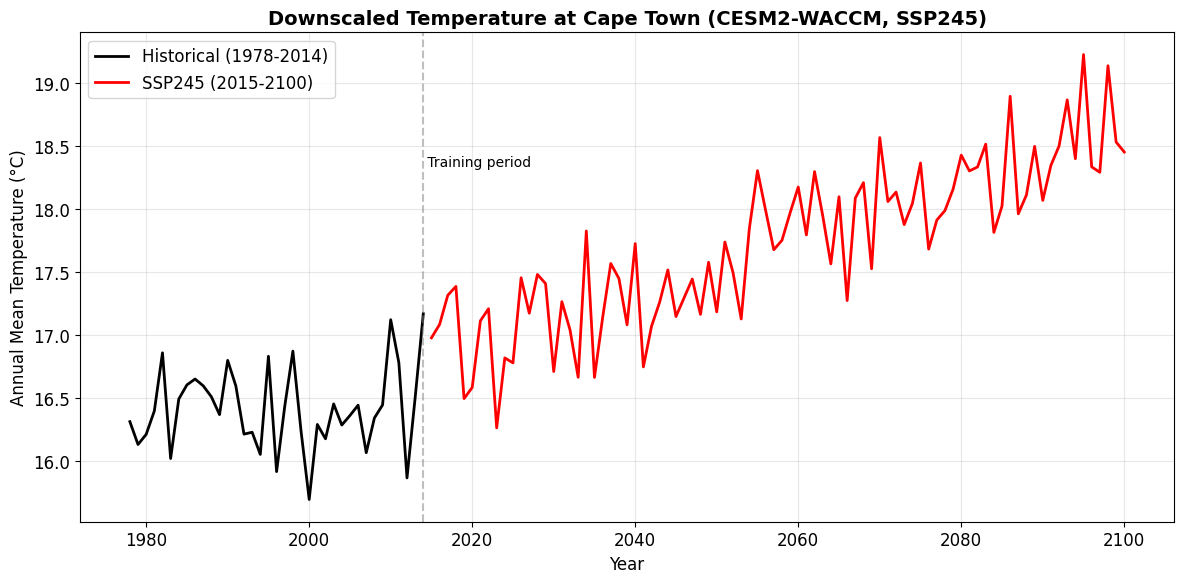

Historical mean: 16.42°C
2090s mean: 18.56°C
Warming: 2.15°C


In [12]:
# Compute annual means
hist_annual = historical_downscaled_ct.groupby("time.year").mean()
scenario_annual = scenario_downscaled_ct.groupby("time.year").mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    hist_annual.year,
    hist_annual - 273.15,
    color="black",
    linewidth=2,
    label="Historical (1978-2014)",
)
ax.plot(
    scenario_annual.year,
    scenario_annual - 273.15,
    color="red",
    linewidth=2,
    label="SSP245 (2015-2100)",
)

ax.axvline(2014, color="gray", linestyle="--", alpha=0.5)
ax.text(2014, ax.get_ylim()[1] * 0.95, " Training period", fontsize=10, va="top")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Annual Mean Temperature (°C)", fontsize=12)
ax.set_title(
    f"Downscaled Temperature at Cape Town ({config.gcm}, {config.scenario})",
    fontsize=14,
    fontweight="bold",
)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Historical mean: {(hist_annual.mean() - 273.15).values:.2f}°C")
print(f"2090s mean: {(scenario_annual.sel(year=slice(2090, 2100)).mean() - 273.15).values:.2f}°C")
print(
    f"Warming: {(scenario_annual.sel(year=slice(2090, 2100)).mean() - hist_annual.mean()).values:.2f}°C"
)

## 5. Check Cache Status

the new pipeline automatically manages caching. let's inspect what's cached:

In [13]:
# Create orchestrator to check status
orchestrator = BCSDOrchestrator()
status = orchestrator.get_status([config])

print("Cache Status:")
print("=" * 60)
for stage, info in status.items():
    cached = info["cached"]
    total = info["total"]
    pct = (cached / total * 100) if total > 0 else 0
    print(f"{stage:25s}: {cached}/{total} ({pct:.0f}%) cached")
    if info["missing"]:
        print(f"  Missing: {', '.join(info['missing'])}")

Cache Status:
prepare_observations     : 1/1 (100%) cached
fit_historical           : 1/1 (100%) cached
transform_scenario       : 1/1 (100%) cached


In [14]:
# List all artifacts in cache
artifacts = pipeline.cache.list_artifacts()
print(f"\nTotal artifacts in {config.environment} environment: {len(artifacts)}")
print("\nArtifact paths:")
for path in artifacts:
    print(f"  {path}")


Total artifacts in qa environment: 2

Artifact paths:
  s3://carbonplan-scratch/srm/bcsd-cache/qa/v1/obs/CESM2-WACCM_tas_lat-48.9634743806813to-20.145569005377542_lon14.446764467644684to39.88857888578887_obs_regridded.icechunk
  s3://carbonplan-scratch/srm/bcsd-cache/qa/v1/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk


## Next steps

### Running via the CLI (recommended)

The CLI handles lineage resolution, member validation, and dispatch automatically:

```bash
# QA smoke-test (South Africa subset, 4 vars × 3 members)
uv run bcsd run --config-path configs/qa/cesm2-waccm-g6.yaml

# Production global run
uv run bcsd run --config-path configs/production/cesm2-waccm-g6.yaml

# Ad-hoc matrix run
uv run bcsd run-matrix \
  --gcm CESM2-WACCM \
  --variable tas --variable pr --variable rsds --variable tasmax \
  --member 001 --member 002 --member 003 \
  --scenario G6-1.5K \
  --predict-period-start 2015 --predict-period-end 2084
```

The `bcsd run` command prints an ensemble member lineage table before starting,
so you can verify the historical / SSP245 bridge assignments at a glance.

### Running via Python

Use `_resolve_lineage` to populate lineage fields, then pass configs to
`BCSDOrchestrator`. `BCSDPipeline.__init__` logs the resolved lineage for
each config it processes.

```python
from srm.bcsd_config import BCSDConfig
from srm.cli import _resolve_lineage
from srm.orchestration import BCSDOrchestrator

configs = [
    BCSDConfig(
        gcm="CESM2-WACCM",
        variable=var,
        ensemble_member=member,
        scenario="G6-1.5K",
        predict_period_start=2015,
        predict_period_end=2084,
        scratch_dir="s3://carbonplan-scratch/srm/bcsd-cache",
        output_dir="s3://carbonplan-srm/output",
        environment="production",
    )
    for member in ("001", "002", "003")
    for var in ("tas", "pr", "rsds", "tasmax")
]

# Resolves historical_ensemble_member and ssp245_ensemble_member on every config.
# GCMs without registered lineage are skipped silently (fields stay None).
configs = _resolve_lineage(configs)

orchestrator = BCSDOrchestrator()
outputs = orchestrator.run_full_workflow(configs, use_coiled=True)
```